# `inspect_moc.ipynb`

Tools for inspecting randoms, catalogs and MOC selection; as well as generating our own MOCs.

In [3]:
## Imports
import time
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from mocpy import WCS as MOCWCS
from mocpy import MOC
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.io import fits
from astropy.table import Table

In [4]:
desi = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits'
    )
desi = desi[1].read(columns=['RA', 'DEC'])
coords_desi = SkyCoord(desi['RA'], desi['DEC'], unit='deg', frame='icrs')

hsc = fio.FITS(
    '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
hsc = hsc[1].read(columns=['RA', 'Dec'])
coords_hsc = SkyCoord(hsc['RA'], hsc['Dec'], unit='deg', frame='icrs')

moc_list = glob.glob(
    f'/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc*.fits'
    )

In [5]:
all_coords_hsc_randoms = [[], []]
data_hsc_path = '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/'
for i in range(0, 10):
    print('Loading MOC:', i)
    hsc_randoms = fio.FITS(
        f'{data_hsc_path}randoms_bulk/hscr{i}.fits'
        )
    # object_id, ra, dec, isprimary, 
    # i_pixelflags_edge, i_pixelflags_bright_objectcenter, 
    # i_pixelflags_saturatedcenter, i_pixelflags_crcenter
    hsc_randoms = hsc_randoms[1].read(columns=[
        'ra', 'dec', 'isprimary', 'i_pixelflags_edge',
        #'i_pixelflags_bright_objectcenter',
        'i_pixelflags_saturatedcenter', 'i_pixelflags_crcenter'
        ])
    ra = hsc_randoms['ra'][0::3]
    dec = hsc_randoms['dec'][0::3]
    mask = hsc_randoms['isprimary']
    if i == 0:
        print(f'{mask.sum()/len(mask)*100:.2f}% of randoms are primary. {mask[0:5]} ...')
    for flag in [ 
        'i_pixelflags_edge', 
        #'i_pixelflags_bright_objectcenter', 
        'i_pixelflags_saturatedcenter', 
        'i_pixelflags_crcenter'
        ]:
        submask = ~hsc_randoms[flag]
        if i == 0:
            print(f'Flag {flag}: {submask.sum()/len(submask)*100:.2f}%')
        mask &= submask

    save_hsc_randoms = hsc_randoms[mask]
    output_filename = f'{data_hsc_path}/randoms/edge_sc_cr_hscr{i}.fits'
    fio.write(output_filename, save_hsc_randoms, clobber=True)
    print(f'Wrote {output_filename}')
    if i == 0:
        print(f'{mask.sum()/len(mask)*100:.2f}% of randoms are primary and not flagged. {mask[0:5]} ...')
    all_coords_hsc_randoms[0].extend(ra)
    all_coords_hsc_randoms[1].extend(dec)
    
coords_hsc_randoms = SkyCoord(
    np.array(all_coords_hsc_randoms[0]) * u.deg, 
    np.array(all_coords_hsc_randoms[1]) * u.deg, 
    frame='icrs'
    )

Loading MOC: 0
72.03% of randoms are primary. [ True  True  True False  True] ...
Flag i_pixelflags_edge: 94.66%
Flag i_pixelflags_saturatedcenter: 99.38%
Flag i_pixelflags_crcenter: 98.94%
Wrote /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc//randoms/edge_sc_cr_hscr0.fits
67.17% of randoms are primary and not flagged. [ True  True False False  True] ...
Loading MOC: 1
Wrote /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc//randoms/edge_sc_cr_hscr1.fits
Loading MOC: 2
Wrote /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc//randoms/edge_sc_cr_hscr2.fits
Loading MOC: 3
Wrote /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc//randoms/edge_sc_cr_hscr3.fits
Loading MOC: 4
Wrote /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc//randoms/edge_sc_cr_hscr4.fits
Loading MOC: 5
Wrote /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc//randoms/edge_sc_cr_hscr5.fits
Loading MOC: 6
Wrote /global/cfs/cdirs/desicollab/users/jc

Computing coords
Coords computed in 10.60 seconds
Number of DESI targets in MOC: 416236
Number of HSC targets in MOC: 25260877
Number of DESI targets: 7809931
Percentage of DESI targets in MOC: 5.33%
Number of HSC randoms: 78001296
DESI targets
HSC targets
DESI targets in MOC


Text(0.5, 1.0, 'HSC-DESI targets on MOCs (subsampled x3)')

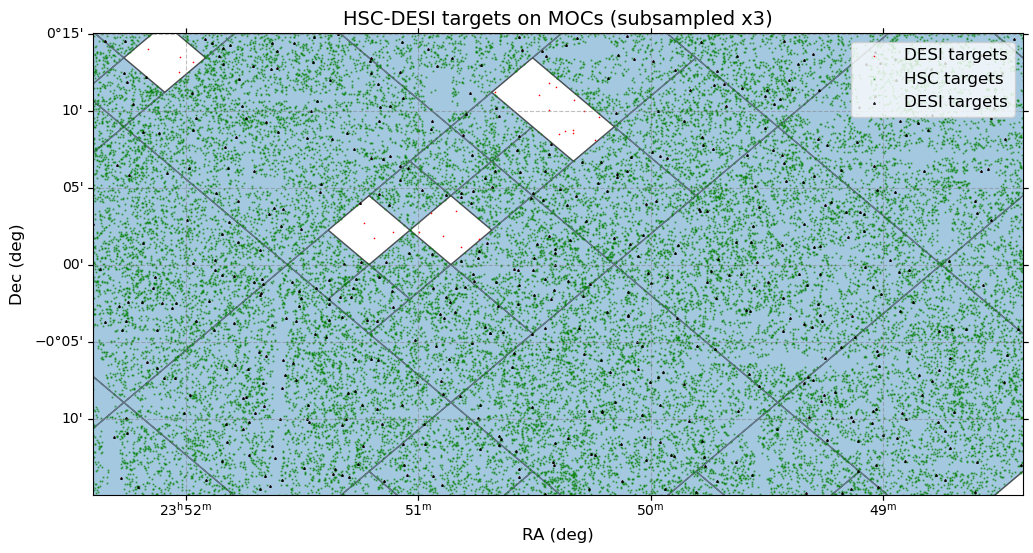

In [7]:
fig = plt.figure(figsize=(12, 6))

with MOCWCS(
    fig,
    fov=0.5 * u.deg,
    center=SkyCoord(-2.4, 0, unit='deg', frame='icrs'),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    projection="AIT"
    ) as wcs: 
    wcs = wcs
ax = fig.add_subplot(projection=wcs)

tr = ax.get_transform('world')

tc = time.time()
print('Computing coords')
lon_hsc = coords_hsc.ra.wrap_at(180 * u.deg).degree
lat_hsc = coords_hsc.dec.degree

lon_desi = coords_desi.ra.wrap_at(180 * u.deg).degree
lat_desi = coords_desi.dec.degree

lon_hsc_randoms = coords_hsc_randoms.ra.wrap_at(180 * u.deg).degree
lat_hsc_randoms = coords_hsc_randoms.dec.degree
print(f'Coords computed in {time.time() - tc:.2f} seconds')

desi_in_moc_n = np.zeros(len(desi), dtype=bool)
for mocf in moc_list:
    moc = MOC.from_fits(mocf)
    desi_in_moc_n |= moc.contains_skycoords(coords_desi)
    moc.fill(ax=ax, wcs=wcs, alpha=0.4, fill=True)
    moc.border(ax=ax, wcs=wcs, alpha=0.4, color="black")

desi_in_moc = desi[np.flatnonzero(desi_in_moc_n)]
coords_desi_in_moc = SkyCoord(desi_in_moc['RA'], desi_in_moc['DEC'], unit='deg', frame='icrs')
lon_desi_in_moc, lat_desi_in_moc = coords_desi_in_moc.ra.wrap_at(180 * u.deg).degree, coords_desi_in_moc.dec.degree

print(f'Number of DESI targets in MOC: {len(desi_in_moc)}')
print(f'Number of HSC targets in MOC: {len(hsc)}')
print(f'Number of DESI targets: {len(desi)}')
print(f'Percentage of DESI targets in MOC: {len(desi_in_moc) / len(desi) * 100:.2f}%')
print(f'Number of HSC randoms: {len(hsc_randoms)}')

print('DESI targets')
ax.scatter(
    lon_desi, 
    lat_desi,
    transform=tr,
    marker='v',
    s=0.05,
    color='red', 
    alpha=1,
    label='DESI targets'
    )

print('HSC targets')
ax.scatter(
    lon_hsc, 
    lat_hsc,
    transform=tr,
    s=0.2, 
    marker='x',
    color='green', 
    alpha=0.7,
    label='HSC targets'
    )

print('DESI targets in MOC')
ax.scatter(
    lon_desi_in_moc, 
    lat_desi_in_moc,
    transform=tr,
    marker='^',
    s=1,
    color='black', 
    alpha=1,
    label='DESI targets'
    )

'''
print('HSC randoms targets')
ax.scatter(
    lon_hsc_randoms,
    lat_hsc_randoms,
    transform=tr,
    s=0.2,
    marker='X',
    color='blue',
    alpha=0.8,
    label='HSC randoms'
    )
'''
ax.grid(color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=12)
ax.set_xlabel('RA (deg)', fontsize=12)
ax.set_ylabel('Dec (deg)', fontsize=12)
ax.set_title('HSC-DESI targets on MOCs (subsampled x3)', fontsize=14)

In [ ]:
ax.scatter(
    lon_hsc_randoms, 
    lat_hsc_randoms,
    transform=tr,
    s=0.2, 
    marker='o',
    color='blue', 
    alpha=0.5,
    label='HSC randoms'
    )

Computing coords
Coords computed in 1.89 seconds
Number of DESI targets in MOC: 416236
Number of HSC targets in MOC: 25260877
Number of DESI targets: 7809931
Percentage of DESI targets in MOC: 5.33%
Number of HSC randoms: 35548738
DESI targets
HSC targets
DESI targets in MOC
HSC randoms targets - hexbin


Text(0.5, 1.0, 'HSC-DESI targets on MOCs')

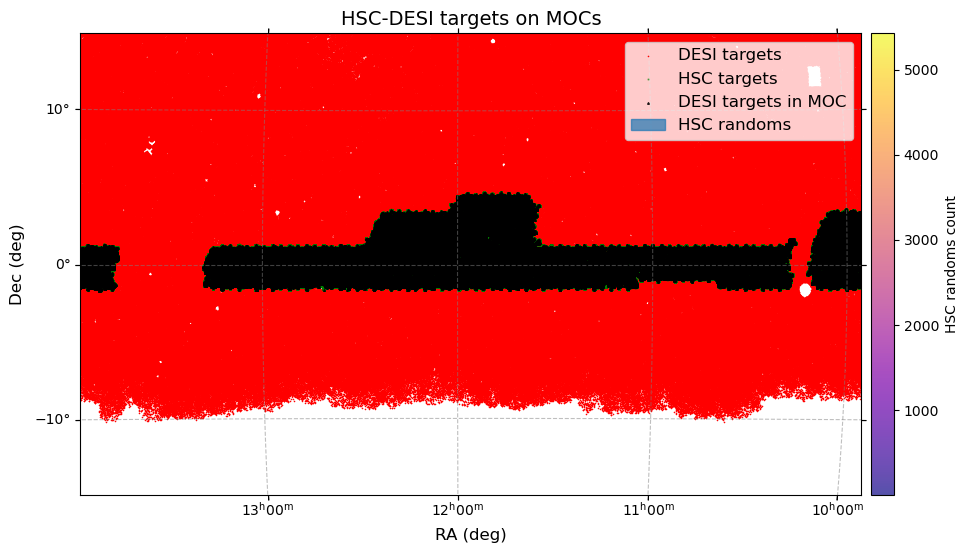

In [41]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=30 * u.deg,
           center=SkyCoord(179, 0, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)

tr = ax.get_transform('world')

tc = time.time()
print('Computing coords')
lon_hsc = coords_hsc.ra.wrap_at(180 * u.deg).degree
lat_hsc = coords_hsc.dec.degree

lon_desi = coords_desi.ra.wrap_at(180 * u.deg).degree
lat_desi = coords_desi.dec.degree

lon_hsc_randoms = coords_hsc_randoms.ra.wrap_at(180 * u.deg).degree
lat_hsc_randoms = coords_hsc_randoms.dec.degree
print(f'Coords computed in {time.time() - tc:.2f} seconds')

desi_in_moc_n = np.zeros(len(desi), dtype=bool)
for mocf in moc_list:
    moc = MOC.from_fits(mocf)
    desi_in_moc_n |= moc.contains_skycoords(coords_desi)
    moc.fill(ax=ax, wcs=wcs, alpha=0.4, fill=True)
    moc.border(ax=ax, wcs=wcs, alpha=0.4, color="black")

desi_in_moc = desi[np.flatnonzero(desi_in_moc_n)]
coords_desi_in_moc = SkyCoord(desi_in_moc['RA'], desi_in_moc['DEC'], unit='deg', frame='icrs')
lon_desi_in_moc, lat_desi_in_moc = coords_desi_in_moc.ra.wrap_at(180 * u.deg).degree, coords_desi_in_moc.dec.degree

print(f'Number of DESI targets in MOC: {len(desi_in_moc)}')
print(f'Number of HSC targets in MOC: {len(hsc)}')
print(f'Number of DESI targets: {len(desi)}')
print(f'Percentage of DESI targets in MOC: {len(desi_in_moc) / len(desi) * 100:.2f}%')
print(f'Number of HSC randoms: {len(hsc_randoms)}')

print('DESI targets')
ax.scatter(
    lon_desi, 
    lat_desi,
    transform=tr,
    marker='v',
    s=0.05,
    color='red', 
    alpha=1,
    label='DESI targets'
    )

print('HSC targets')
ax.scatter(
    lon_hsc, 
    lat_hsc,
    transform=tr,
    s=0.2, 
    marker='x',
    color='green', 
    alpha=0.7,
    label='HSC targets'
    )

print('DESI targets in MOC')
ax.scatter(
    lon_desi_in_moc, 
    lat_desi_in_moc,
    transform=tr,
    marker='^',
    s=1,
    color='black', 
    alpha=1,
    label='DESI targets in MOC'
    )

print('HSC randoms targets - hexbin')
# Replace the scatter plot with hexbin for HSC randoms
hb = ax.hexbin(
    coords_hsc_randoms.ra.wrap_at(180 * u.deg).degree,
    coords_hsc_randoms.dec.degree,
    transform=tr,
    gridsize=300,  # Adjust this value to control hexbin resolution
    cmap='plasma',  # Use a blue colormap
    alpha=0.7,
    mincnt=1,
    label='HSC randoms'
)
# Add a colorbar for the hexbin plot
cbar = plt.colorbar(hb, ax=ax, pad=0.01)
cbar.set_label('HSC randoms count')

ax.grid(color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=12)
ax.set_xlabel('RA (deg)', fontsize=12)
ax.set_ylabel('Dec (deg)', fontsize=12)
ax.set_title('HSC-DESI targets on MOCs', fontsize=14)

/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc1.fits


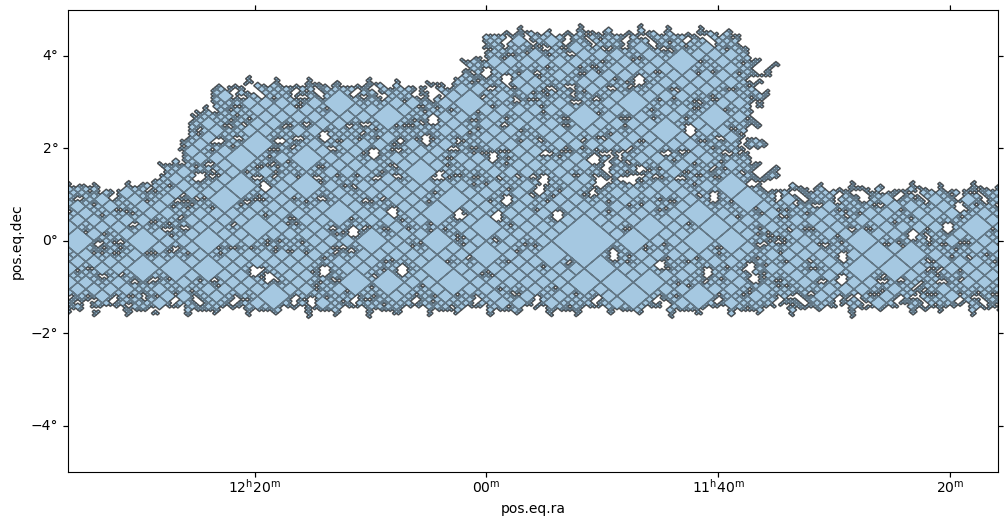

In [52]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=10 * u.deg,
           center=SkyCoord(179, 0, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)

tr = ax.get_transform('world')

mocidx = 1
print(moc_list[mocidx])
moc = MOC.from_fits(moc_list[mocidx])
moc.fill(ax=ax, wcs=wcs, alpha=0.4, fill=True)
moc.border(ax=ax, wcs=wcs, alpha=0.4, color="black")

In [5]:
print(len(lon_desi_in_moc))

416236


In [37]:
from desitarget.targetmask import desi_mask

desi_tgt = desi['DESI_TARGET']

is_bgs  = (desi_tgt & desi_mask.BGS_ANY != 0)   #- instead of 2**60
is_lrg  = (desi_tgt & desi_mask.LRG != 0)
is_elg  = (desi_tgt & desi_mask.ELG != 0)
is_qso  = (desi_tgt & desi_mask.QSO != 0)
is_mws  = (desi_tgt & desi_mask.MWS_ANY != 0)
is_scnd = (desi_tgt & desi_mask.SCND_ANY != 0)
masks = {
    'BGS': is_bgs,
    'LRG': is_lrg,
    'ELG': is_elg,
    'QSO': is_qso,
    #'MWS': is_mws,
    #'SCND': is_scnd
}


ValueError: no field of name DESI_TARGET